# **Exposure at default (EAD) modeling**

This notebook presents a methodology for building a model to estimate EAD – Exposure at Default.We work with the dataset that has already been cleaned and preprocessed in the earlier steps.

EAD quantifies the total exposure outstanding at the time a borrower defaults.

## **Base imports**

In [ ]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from datetime import datetime

from sklearn import __version__ as sklearn_version
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

In [ ]:
%matplotlib inline
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
print(f'Python {sys.version.split()[0]}')
print(f'pandas=={pd.__version__}')
print(f'numpy=={np.__version__}')
print(f'sklearn=={sklearn_version}')
print(f'matplotlib=={matplotlib.__version__}')
print(f'seaborn=={sns.__version__}')
print(f'xgboost=={xgb.__version__}')

Python 3.12.12
pandas==2.2.2
numpy==2.0.2
sklearn==1.6.1
matplotlib==3.10.0
seaborn==0.13.2
xgboost==3.1.2


## **Loading the data**

In [ ]:
df = pd.read_csv('processed-data/loan_data_processed.csv')

In [ ]:
selected_cols = [
    "id", "member_id", "loan_amnt", "funded_amnt", "term", "int_rate", "installment", "grade", "emp_length",
    "home_ownership", "annual_inc", "issue_d", "loan_status", "purpose", "addr_state", "dti", "delinq_2yrs",
    "earliest_cr_line", "verification_status", "initial_list_status", "inq_last_6mths", "open_acc", "pub_rec",
    "total_acc", "total_rev_hi_lim", "recoveries", 'months_since_issue_date', 'months_since_earliest_cr_line', 'total_rec_prncp'
]

In [ ]:
df = df.loc[:, selected_cols]
df.head()

,id,member_id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,verification_status,initial_list_status,inq_last_6mths,open_acc,pub_rec,total_acc,total_rev_hi_lim,recoveries,months_since_issue_date,months_since_earliest_cr_line,total_rec_prncp
0,1077501,1296599,5000.0,5000.0,36,10.65,162.87,B,10.0,RENT,24000.0,2011-12-01,Fully Paid,credit_card,AZ,27.65,0.0,1985-01-01,Verified,f,1.0,3.0,0.0,9.0,NaN,0.00,72.010512,394.940867,5000.00
1,1077430,1314167,2500.0,2500.0,60,15.27,59.83,C,0.0,RENT,30000.0,2011-12-01,Charged Off,car,GA,1.00,0.0,1999-04-01,Source Verified,f,5.0,3.0,0.0,4.0,NaN,117.08,72.010512,224.014455,456.46
2,1077175,1313524,2400.0,2400.0,36,15.96,84.33,C,10.0,RENT,12252.0,2011-12-01,Fully Paid,small_business,IL,8.72,0.0,2001-11-01,Not Verified,f,2.0,2.0,0.0,10.0,NaN,0.00,72.010512,192.969777,2400.00
3,1076863,1277178,10000.0,10000.0,36,13.49,339.31,C,10.0,RENT,49200.0,2011-12-01,Fully Paid,other,CA,20.00,0.0,1996-02-01,Source Verified,f,1.0,10.0,0.0,37.0,NaN,0.00,72.010512,261.957950,10000.00
4,1075358,1311748,3000.0,3000.0,60,12.69,67.79,B,1.0,RENT,80000.0,2011-12-01,Current,other,OR,17.94,0.0,1996-01-01,Source Verified,f,0.0,15.0,0.0,38.0,NaN,0.00,72.010512,262.976347,2233.10


In [ ]:
df["earliest_cr_line"].isnull().sum()

np.int64(29)

In [ ]:
df["earliest_cr_line"] = df["earliest_cr_line"].fillna(df["issue_d"])

## **Defining the target variable**

When modeling EAD, it is standard practice to focus on loans where the borrower has defaulted, as this allows us to measure the exposure at the time of default. For this purpose, we will consider only written-off loans, indicated by the loan_status values:

- 'Charged Off'

- 'Does not meet the credit policy. Status: Charged Off'

In [ ]:
default_categories = [
    "Charged Off",
    "Does not meet the credit policy. Status:Charged Off"
]

df = df[df["loan_status"].isin(default_categories)]

From the data:

- `funded_amnt` reflects the total amount the borrower applied for.

- `total_rec_prncp` reflects the amount of principal that has been repaid.

Thus, Exposure at Default (EAD) can be calculated as:

$EAD = funded\_amnt - total\_rec\_prncp$

For simplicity, we will instead model the Credit Conversion Factor (CCF), which represents the portion of the original loan that remains outstanding at the time of default:

$CCF = \frac{EAD}{funded\_amnt} = \frac{funded\_amnt - total\_rec\_prncp}{funded\_amnt}$

In [ ]:
target_variable = "CCF"

df[target_variable] = (df["funded_amnt"] - df["total_rec_prncp"]) / df["funded_amnt"]
df[target_variable].describe()

,CCF
count,43236.000000
mean,0.735952
std,0.200742
min,0.000438
25%,0.632088
50%,0.789908
75%,0.888543
max,1.000000


In [ ]:
df[target_variable].isnull().sum()

np.int64(0)

## **Train / test split**

Next, we split the dataset into training and test sets to prevent any data leakage:

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.20, random_state=99)

## **Analyzing the target variable**

From the visualizations, it is clear that the target variable is relatively evenly distributed. Therefore, there is no need to use a Zero-Inflated Regression model for this case.

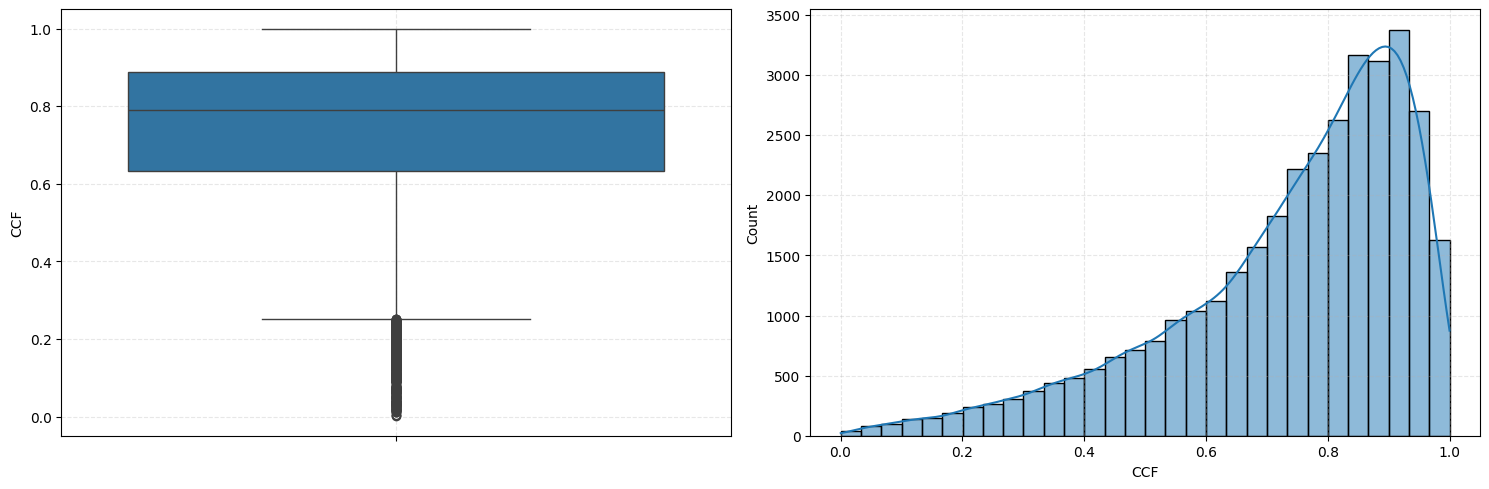

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_train, y=target_variable, ax=ax1)
sns.histplot(data=df_train, x=target_variable, bins=30, ax=ax2, kde=True)

ax1.grid(alpha=0.3, linestyle="--")
ax2.grid(alpha=0.3, linestyle="--")

plt.tight_layout()

## **Analyzing categorical variables**

The same categorical variables defined in the PD model will be used here to examine their relationship with the target variable:

- `grade`

- `home_ownership`

- `addr_state`

- `verification_status`

- `purpose`

- `initial_list_status`

In [ ]:
df_train_mod = df_train.copy()
df_test_mod = df_test.copy()

In [ ]:
variable = "grade"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


grade
C    9699
D    7922
B    7369
E    4701
F    2199
A    2054
G     644
Name: count, dtype: int64


In [ ]:
variable = "home_ownership"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


home_ownership
RENT        16206
MORTGAGE    15315
OWN          3030
OTHER          30
NONE            7
Name: count, dtype: int64


In [ ]:
print("Original train categories:", df_train_mod['home_ownership'].unique())

# Define the mapping - combine these into one category
category_mapping = {
    'OTHER': 'NONE_OTHER_RENT_ANY',
    'NONE': 'NONE_OTHER_RENT_ANY',
    'ANY': 'NONE_OTHER_RENT_ANY',
    'RENT': 'NONE_OTHER_RENT_ANY',  # Keep RENT as part of the combined group
    'OWN': 'OWN',              # Keep as is
    'MORTGAGE': 'MORTGAGE'     # Keep as is
}

# Apply the mapping to the home_ownership column
df_train_mod['home_ownership'] = df_train_mod['home_ownership'].replace(category_mapping)


print("New train categories:", df_train_mod['home_ownership'].unique())
print("Value counts:")
print(df_train_mod['home_ownership'].value_counts())

Original train categories: ['MORTGAGE' 'RENT' 'OWN' 'NONE' 'OTHER']
New train categories: ['MORTGAGE' 'NONE_OTHER_RENT_ANY' 'OWN']
Value counts:
home_ownership
NONE_OTHER_RENT_ANY    16243
MORTGAGE               15315
OWN                     3030
Name: count, dtype: int64


In [ ]:
print("Original test categories:", df_test_mod['home_ownership'].unique())

df_test_mod['home_ownership'] = df_test_mod['home_ownership'].replace(category_mapping)

print("New test categories:", df_test_mod['home_ownership'].unique())
print("Value counts:")
print(df_test_mod['home_ownership'].value_counts())

Original test categories: ['RENT' 'MORTGAGE' 'OWN' 'OTHER' 'NONE']
New test categories: ['NONE_OTHER_RENT_ANY' 'MORTGAGE' 'OWN']
Value counts:
home_ownership
NONE_OTHER_RENT_ANY    4061
MORTGAGE               3832
OWN                     755
Name: count, dtype: int64


In [ ]:
variable = "addr_state"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].unique())
print(df_train_mod[variable].nunique())

0 missing rows!


['FL' 'NJ' 'VA' 'TX' 'KY' 'NY' 'OH' 'MD' 'CA' 'AZ' 'OR' 'AL' 'CT' 'RI'
 'IL' 'KS' 'PA' 'WI' 'WA' 'CO' 'GA' 'IN' 'NV' 'MN' 'MO' 'UT' 'MS' 'MI'
 'MA' 'TN' 'NC' 'AR' 'MT' 'LA' 'DE' 'HI' 'NH' 'SC' 'OK' 'WV' 'VT' 'NM'
 'DC' 'AK' 'SD' 'WY' 'NE' 'IA' 'ID']
49


In [ ]:
print("Original train categories:", df_train_mod['addr_state'].unique())

# Define the mapping
category_mapping = {
    "NV_ND_ME_NE_IA": ["NV", "ND", "ME", "NE", "IA"],
    "HI": ["HI"],
    "FL": ["FL"],
    "AL_OK_LA": ["AL", "OK", "LA"],
    "NY": ["NY"],
    "MO": ["MO"],
    "MD_NJ_VA_NC_NM": ["NJ", "VA", "NC", "NM", "MD"],
    "CA": ["CA"],
    "TN_AZ_MI": ["TN", "AZ", "MI"],
    "KY_RI_ID": ["KY", "RI", "ID"],
    "PA_AR_OH_UT": ["PA", "AR", "OH", "UT"],
    "MN_MA_SD": ["MN", "MA", "SD"],
    "IN_OR_WA_GA": ["IN", "OR", "WA", "GA"],
    "WI_DE": ["WI", "DE"],
    "IL": ["IL"],
    "TX": ["TX"],
    "CT": ["CT"],
    "WV_KS_CO_SC": ["WV", "KS", "CO", "SC"],
    "MS_AK_MT_VT": ["MS", "AK", "MT", "VT"],
    "NH_WY_DC": ["NH", "WY", "DC"]
}

# Create flattened mapping for .replace()
flat_mapping = {}
for new_group, old_states in category_mapping.items():
    for state in old_states:
        flat_mapping[state] = new_group

print(f"Created {len(flat_mapping)} state-to-group mappings")

# Apply the mapping
df_train_mod['addr_state'] = df_train_mod['addr_state'].replace(flat_mapping)

print("New train categories:", df_train_mod['addr_state'].unique())
print("Number of new categories:", df_train_mod['addr_state'].nunique())
print("\nValue counts:")
print(df_train_mod['addr_state'].value_counts())

Original train categories: ['FL' 'NJ' 'VA' 'TX' 'KY' 'NY' 'OH' 'MD' 'CA' 'AZ' 'OR' 'AL' 'CT' 'RI'
 'IL' 'KS' 'PA' 'WI' 'WA' 'CO' 'GA' 'IN' 'NV' 'MN' 'MO' 'UT' 'MS' 'MI'
 'MA' 'TN' 'NC' 'AR' 'MT' 'LA' 'DE' 'HI' 'NH' 'SC' 'OK' 'WV' 'VT' 'NM'
 'DC' 'AK' 'SD' 'WY' 'NE' 'IA' 'ID']
Created 51 state-to-group mappings
New train categories: ['FL' 'MD_NJ_VA_NC_NM' 'TX' 'KY_RI_ID' 'NY' 'PA_AR_OH_UT' 'CA' 'TN_AZ_MI'
 'IN_OR_WA_GA' 'AL_OK_LA' 'CT' 'IL' 'WV_KS_CO_SC' 'WI_DE' 'NV_ND_ME_NE_IA'
 'MN_MA_SD' 'MO' 'MS_AK_MT_VT' 'HI' 'NH_WY_DC']
Number of new categories: 20

Value counts:
addr_state
CA                5579
MD_NJ_VA_NC_NM    4539
NY                3095
PA_AR_OH_UT       2837
FL                2712
IN_OR_WA_GA       2710
TX                2317
TN_AZ_MI          2089
MN_MA_SD          1490
WV_KS_CO_SC       1331
AL_OK_LA          1266
IL                1198
MO                 626
NV_ND_ME_NE_IA     615
WI_DE              497
KY_RI_ID           494
CT                 457
MS_AK_MT_VT        275


In [ ]:
print("Original test categories:", df_test_mod['addr_state'].unique())

df_test_mod['addr_state'] = df_test_mod['addr_state'].replace(flat_mapping)

print("New test categories:", df_test_mod['addr_state'].unique())
print("Value counts:")
print(df_test_mod['addr_state'].value_counts())

Original test categories: ['CA' 'AZ' 'OH' 'TX' 'NJ' 'NY' 'PA' 'CT' 'IN' 'NC' 'WA' 'OK' 'TN' 'MD'
 'NV' 'RI' 'MO' 'SC' 'LA' 'CO' 'MN' 'VA' 'OR' 'AL' 'IL' 'FL' 'KS' 'WI'
 'GA' 'MA' 'MI' 'MT' 'WV' 'NM' 'KY' 'HI' 'UT' 'AR' 'NH' 'DC' 'AK' 'WY'
 'DE' 'SD' 'MS' 'VT' 'NE']
New test categories: ['CA' 'TN_AZ_MI' 'PA_AR_OH_UT' 'TX' 'MD_NJ_VA_NC_NM' 'NY' 'CT'
 'IN_OR_WA_GA' 'AL_OK_LA' 'NV_ND_ME_NE_IA' 'KY_RI_ID' 'MO' 'WV_KS_CO_SC'
 'MN_MA_SD' 'IL' 'FL' 'WI_DE' 'MS_AK_MT_VT' 'HI' 'NH_WY_DC']
Value counts:
addr_state
CA                1432
MD_NJ_VA_NC_NM    1137
NY                 843
PA_AR_OH_UT        728
FL                 688
IN_OR_WA_GA        647
TX                 566
TN_AZ_MI           535
MN_MA_SD           344
WV_KS_CO_SC        326
IL                 291
AL_OK_LA           284
NV_ND_ME_NE_IA     152
CT                 133
MO                 131
WI_DE              130
KY_RI_ID           113
MS_AK_MT_VT         58
NH_WY_DC            58
HI                  52
Name: count, dtype: int64


In [ ]:
variable = "verification_status"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


verification_status
Verified           14704
Source Verified    10114
Not Verified        9770
Name: count, dtype: int64


In [ ]:
variable = "purpose"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


purpose
debt_consolidation    20911
credit_card            5958
other                  2333
home_improvement       1757
small_business         1105
major_purchase          656
medical                 424
car                     346
moving                  323
wedding                 226
house                   223
vacation                214
educational              69
renewable_energy         43
Name: count, dtype: int64


In [ ]:
print("Original train categories:", df_train_mod['purpose'].unique())

# Define the mapping
category_mapping = {
    "car": ["car"],
    "credit_card": ["credit_card"],
    "major_purchase_home_improvement": ["major_purchase", "home_improvement"],
    "debt_consolidation": ["debt_consolidation"],
    "vacation_wedding": ["vacation", "wedding"],
    "medical": ['medical'],
    "other": ["other"],
    "renewable_energy_house_moving": ["renewable_energy", "house", "moving"],
    "educational_small_business": ["small_business", "educational"],
}

# Create flattened mapping for .replace()
flat_mapping = {}
for new_group, old_purposes in category_mapping.items():
    for purpose in old_purposes:
        flat_mapping[purpose] = new_group

print(f"Created {len(flat_mapping)} purpose-to-group mappings")

# Apply the mapping
df_train_mod['purpose'] = df_train_mod['purpose'].replace(flat_mapping)

print("New train categories:", df_train_mod['purpose'].unique())
print("Number of new categories:", df_train_mod['purpose'].nunique())
print("\nValue counts:")
print(df_train_mod['purpose'].value_counts())

Original train categories: ['credit_card' 'debt_consolidation' 'other' 'major_purchase'
 'small_business' 'house' 'home_improvement' 'wedding' 'car'
 'renewable_energy' 'vacation' 'moving' 'medical' 'educational']
Created 14 purpose-to-group mappings
New train categories: ['credit_card' 'debt_consolidation' 'other'
 'major_purchase_home_improvement' 'educational_small_business'
 'renewable_energy_house_moving' 'vacation_wedding' 'car' 'medical']
Number of new categories: 9

Value counts:
purpose
debt_consolidation                 20911
credit_card                         5958
major_purchase_home_improvement     2413
other                               2333
educational_small_business          1174
renewable_energy_house_moving        589
vacation_wedding                     440
medical                              424
car                                  346
Name: count, dtype: int64


In [ ]:
print("Original test categories:", df_test_mod['purpose'].unique())

df_test_mod['purpose'] = df_test_mod['purpose'].replace(flat_mapping)

print("New test categories:", df_test_mod['purpose'].unique())
print("Value counts:")
print(df_test_mod['purpose'].value_counts())

Original test categories: ['debt_consolidation' 'major_purchase' 'home_improvement' 'credit_card'
 'other' 'medical' 'house' 'vacation' 'wedding' 'educational' 'moving'
 'car' 'small_business' 'renewable_energy']
New test categories: ['debt_consolidation' 'major_purchase_home_improvement' 'credit_card'
 'other' 'medical' 'renewable_energy_house_moving' 'vacation_wedding'
 'educational_small_business' 'car']
Value counts:
purpose
debt_consolidation                 5216
credit_card                        1491
major_purchase_home_improvement     615
other                               559
educational_small_business          308
renewable_energy_house_moving       149
medical                             121
vacation_wedding                     97
car                                  92
Name: count, dtype: int64


In [ ]:
variable = "initial_list_status"

In [ ]:
print(f"{df_train_mod[variable].isnull().sum():,} missing rows!\n\n")
print(df_train_mod[variable].value_counts())

0 missing rows!


initial_list_status
f    25649
w     8939
Name: count, dtype: int64


In [ ]:
df_train_mod.columns.equals(df_test_mod.columns)

True

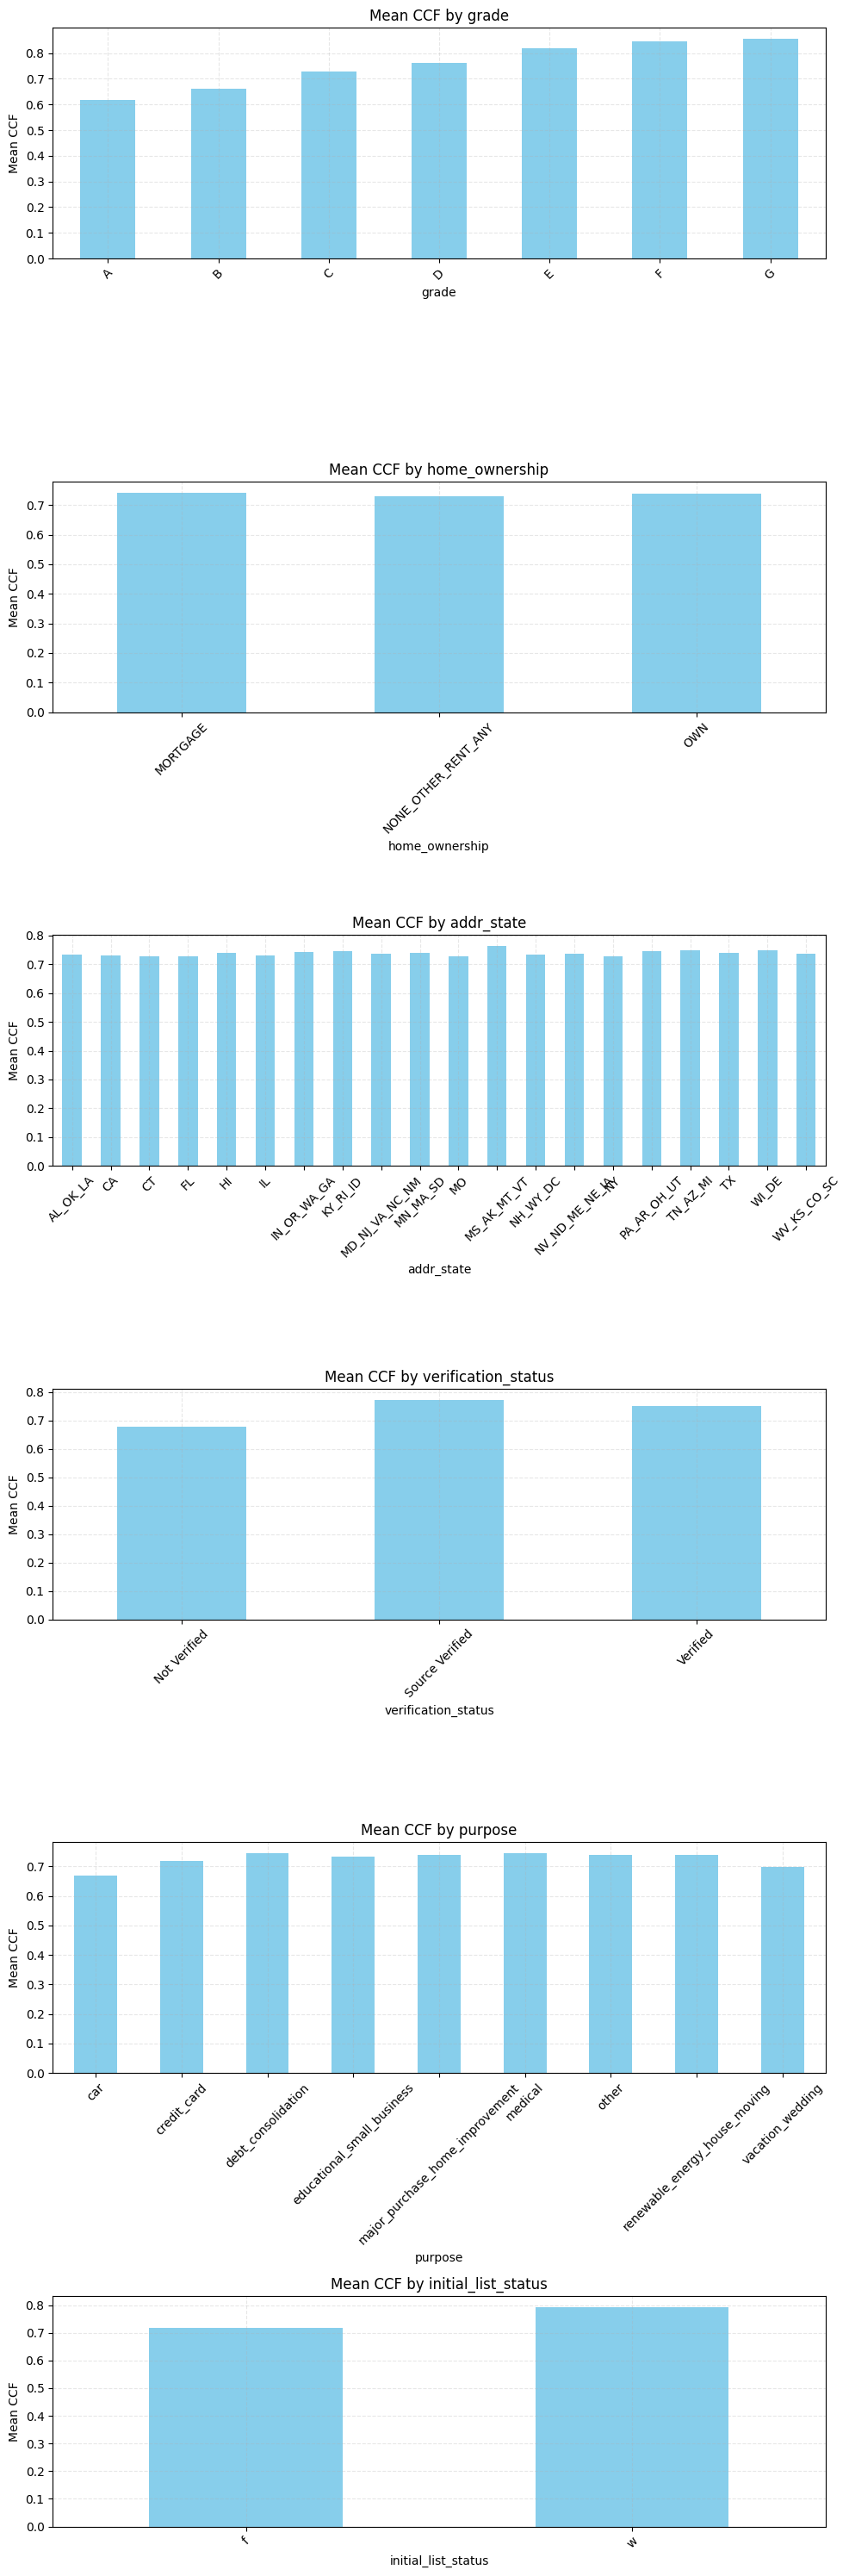

In [ ]:
categorical_vars = [
    "grade",
    "home_ownership",
    "addr_state",
    "verification_status",
    "purpose",
    "initial_list_status"
]

plt.figure(figsize=(10, 30))

for i, var in enumerate(categorical_vars, 1):
    plt.subplot(len(categorical_vars), 1, i)
    df_train_mod.groupby(var)['CCF'].mean().sort_index().plot(kind='bar', color='skyblue', ax=plt.gca())
    plt.xticks(rotation=45)
    plt.ylabel('Mean CCF')
    plt.title(f'Mean CCF by {var}')
    plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


When examining the categorical variables, we notice that for `grade` and `verification_status`, the riskier categories tend to have a higher CCF, meaning a larger portion of the original loan remains outstanding at default. For the other categorical variables, the mean CCF is fairly consistent across categories, showing little variation.

## **Encoding categorical variables**

In [ ]:
y_train = df_train_mod['CCF']
y_test = df_test_mod['CCF']

In [ ]:
cat_cols = [
    'grade',
    'home_ownership',
    'addr_state',
    'verification_status',
    'purpose',
    'initial_list_status'
]

In [ ]:
encoder = OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False)

In [ ]:
train_encoded = encoder.fit_transform(df_train_mod[cat_cols])
test_encoded = encoder.transform(df_test_mod[cat_cols])

In [ ]:
feature_names = encoder.get_feature_names_out(cat_cols)

In [ ]:
df_train_encoded = pd.DataFrame(train_encoded, columns=feature_names, index=df_train_mod.index)
df_test_encoded = pd.DataFrame(test_encoded, columns=feature_names, index=df_test_mod.index)

In [ ]:
df_train_encoded.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_NONE_OTHER_RENT_ANY,home_ownership_OWN,addr_state_AL_OK_LA,addr_state_CA,addr_state_CT,addr_state_FL,addr_state_HI,addr_state_IL,addr_state_IN_OR_WA_GA,addr_state_KY_RI_ID,addr_state_MD_NJ_VA_NC_NM,addr_state_MN_MA_SD,addr_state_MO,addr_state_MS_AK_MT_VT,addr_state_NH_WY_DC,addr_state_NV_ND_ME_NE_IA,addr_state_NY,addr_state_PA_AR_OH_UT,addr_state_TN_AZ_MI,addr_state_TX,addr_state_WI_DE,addr_state_WV_KS_CO_SC,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational_small_business,purpose_major_purchase_home_improvement,purpose_medical,purpose_other,purpose_renewable_energy_house_moving,purpose_vacation_wedding,initial_list_status_f,initial_list_status_w
210440,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
360756,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
29015,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
45135,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
126736,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
df_test_encoded.head()

,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_NONE_OTHER_RENT_ANY,home_ownership_OWN,addr_state_AL_OK_LA,addr_state_CA,addr_state_CT,addr_state_FL,addr_state_HI,addr_state_IL,addr_state_IN_OR_WA_GA,addr_state_KY_RI_ID,addr_state_MD_NJ_VA_NC_NM,addr_state_MN_MA_SD,addr_state_MO,addr_state_MS_AK_MT_VT,addr_state_NH_WY_DC,addr_state_NV_ND_ME_NE_IA,addr_state_NY,addr_state_PA_AR_OH_UT,addr_state_TN_AZ_MI,addr_state_TX,addr_state_WI_DE,addr_state_WV_KS_CO_SC,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational_small_business,purpose_major_purchase_home_improvement,purpose_medical,purpose_other,purpose_renewable_energy_house_moving,purpose_vacation_wedding,initial_list_status_f,initial_list_status_w
165527,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28900,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
109700,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
185371,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
443870,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_train_encoded.columns.equals(df_test_encoded.columns)

True

## **Analyzing numerical variables**

Since the goal is to build a regression model that does not need to be directly interpretable or explainable for external regulators, there is no requirement to bin numeric variables. Therefore, we can move directly to exploratory data analysis.

In [ ]:
num_cols = [
    "term",
    "emp_length",
    "months_since_issue_date",
    "int_rate",
    "funded_amnt",
    "months_since_earliest_cr_line",
    "annual_inc",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "total_acc",
    "dti",
    "total_rev_hi_lim",
]

df_train_encoded = pd.concat([df_train_encoded, df_train_mod[num_cols].astype(float), y_train], axis = 1)
df_test_encoded = pd.concat([df_test_encoded, df_test_mod[num_cols].astype(float), y_test], axis = 1)

In [ ]:
variable = "emp_length"
df_train_encoded[variable] = df_train_encoded[variable].fillna(0)
df_test_encoded[variable] = df_test_encoded[variable].fillna(0)

In [ ]:
variable = 'months_since_earliest_cr_line'
df_train_encoded[variable] = df_train_encoded[variable].fillna(df_train_encoded['months_since_issue_date'])
df_test_encoded[variable] = df_test_encoded[variable].fillna(df_test_encoded['months_since_issue_date'])

In [ ]:
variable = "annual_inc"
df_train_encoded[variable] = df_train_encoded[variable].fillna(df_train_encoded[variable].min())
df_test_encoded[variable] = df_test_encoded[variable].fillna(df_test_encoded[variable].min())

In [ ]:
variable = "delinq_2yrs"
df_train_encoded[variable] = df_train_encoded[variable].fillna(df_train_encoded[variable].max())
df_test_encoded[variable] = df_test_encoded[variable].fillna(df_test_encoded[variable].max())

In [ ]:
variable = "inq_last_6mths"
df_train_encoded[variable] = df_train_encoded[variable].fillna(df_train_encoded[variable].max())
df_test_encoded[variable] = df_test_encoded[variable].fillna(df_test_encoded[variable].max())

In [ ]:
variable = "open_acc"
df_train_encoded[variable] = df_train_encoded[variable].fillna(df_train_encoded[variable].max())
df_test_encoded[variable] = df_test_encoded[variable].fillna(df_test_encoded[variable].max())

In [ ]:
variable = "pub_rec"
df_train_encoded[variable] = df_train_encoded[variable].fillna(df_train_encoded[variable].min())
df_test_encoded[variable] = df_test_encoded[variable].fillna(df_test_encoded[variable].min())

In [ ]:
variable = "total_acc"
df_train_encoded[variable] = df_train_encoded[variable].fillna(df_train_encoded[variable].min())
df_test_encoded[variable] = df_test_encoded[variable].fillna(df_test_encoded[variable].min())

In [ ]:
variable = "dti"
df_train_encoded[variable] = df_train_encoded[variable].fillna(df_train_encoded[variable].max())
df_test_encoded[variable] = df_test_encoded[variable].fillna(df_test_encoded[variable].max())

In [ ]:
variable = "total_rev_hi_lim"
df_train_encoded[variable] = df_train_encoded[variable].fillna(df_train_encoded['funded_amnt'])
df_test_encoded[variable] = df_test_encoded[variable].fillna(df_test_encoded['funded_amnt'].max())

In [ ]:
df_train_encoded.isnull().sum()

,0
grade_A,0
grade_B,0
grade_C,0
grade_D,0
grade_E,0
grade_F,0
grade_G,0
home_ownership_MORTGAGE,0
home_ownership_NONE_OTHER_RENT_ANY,0
home_ownership_OWN,0


In [ ]:
df_test_encoded.isnull().sum()

,0
grade_A,0
grade_B,0
grade_C,0
grade_D,0
grade_E,0
grade_F,0
grade_G,0
home_ownership_MORTGAGE,0
home_ownership_NONE_OTHER_RENT_ANY,0
home_ownership_OWN,0


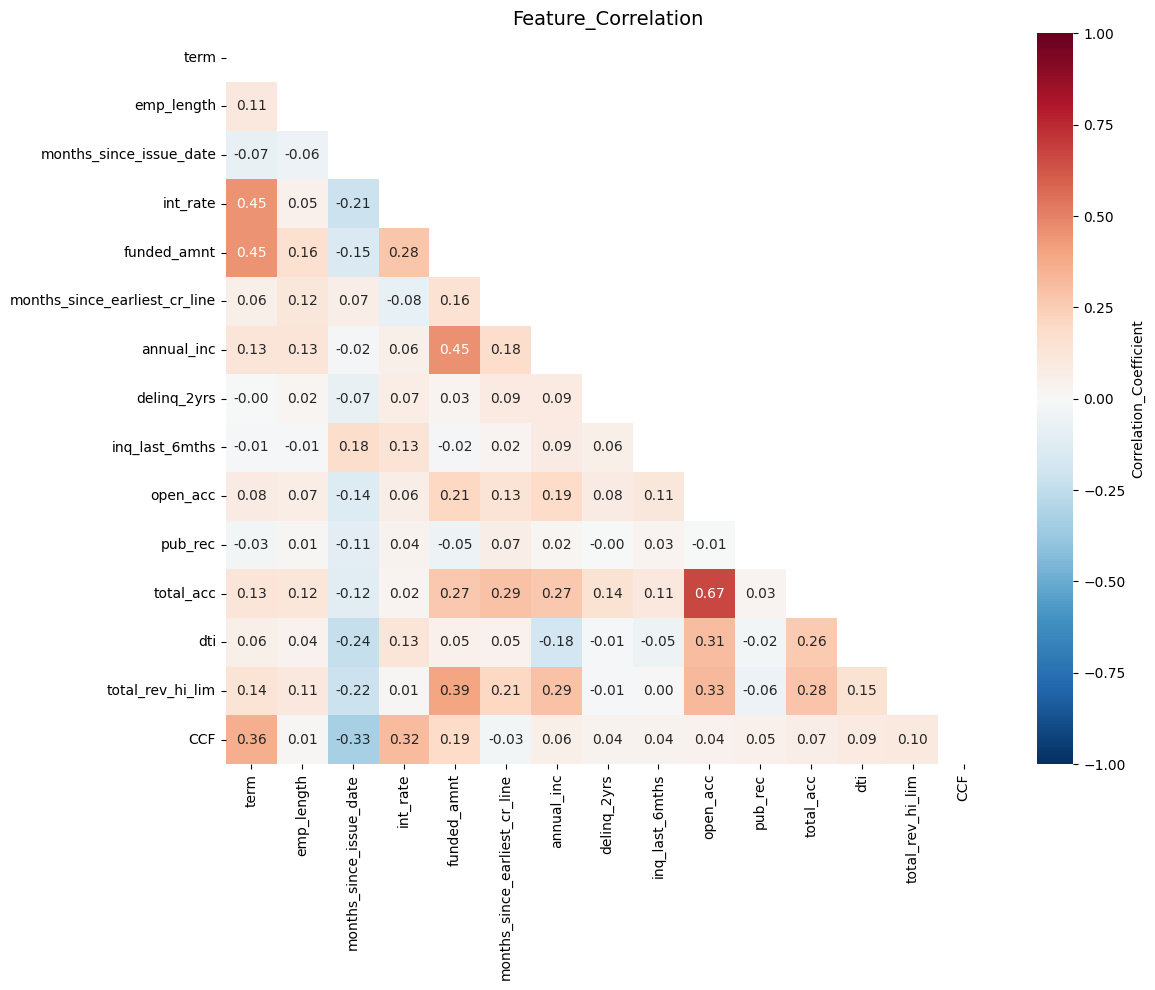

In [ ]:
corr = df_train_encoded[num_cols + ['CCF']].corr()

mask = np.triu(corr)

plt.figure(figsize = (12, 10))
sns.heatmap(corr,
            mask = mask,
            annot = True,
            fmt = ".2f",
            cmap = 'RdBu_r',
            vmin = -1, vmax = 1,
            cbar_kws = {'label': 'Correlation_Coefficient'})

plt.title('Feature_Correlation', fontsize = 14)
plt.tight_layout()

Based on the visualizations above, none of the numerical variables show a strong correlation with the target. Therefore, we will turn to more sophisticated models, such as XGBoost, which are better suited to uncover complex patterns that can effectively predict the target.

## **Modeling**

For CCF, the target distribution does not exhibit a large spike of zeros or other extreme irregularities, so a standard regression approach is appropriate.

In [ ]:
X_train = df_train_encoded.drop(columns = 'CCF')
X_test = df_test_encoded.drop(columns = 'CCF')

y_train = df_train_encoded['CCF']
y_test = df_test_encoded['CCF']

In [ ]:
regressor = XGBRegressor(random_state=99,
                         objective="reg:squarederror",
                         n_estimators=100,
                         max_depth=6)

regressor.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_train = regressor.predict(X_train)

In [ ]:
y_pred_test = regressor.predict(X_test)

Clipping predicted CCF values between 0 and 1:

In [ ]:
y_pred_train = np.clip(y_pred_train, 0, 1)

In [ ]:
y_pred_test = np.clip(y_pred_test, 0, 1)

## **Assessing model performance**

Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) are calculated on both training and test sets to quantify prediction accuracy. These metrics provide complementary insights: RMSE penalizes larger errors more heavily, while MAE gives a straightforward average of absolute differences.

Histograms comparing predicted vs actual recovery rates allow us to visually assess how well the model captures the distribution of CCFs.

Additionally, residual distribution plots show the spread of prediction errors for both training and test sets. Histograms highlight where predictions tend to under- or overestimate the CCFs, helping to identify potential biases or areas for improvement.

In [ ]:
# Training set
rmse_train = (mean_squared_error(y_train, y_pred_train))**0.5
mae_train = mean_absolute_error(y_train, y_pred_train)

# Test set
rmse_test = (mean_squared_error(y_test, y_pred_test))**0.5
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Train RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}")

Train RMSE: 0.1337, MAE: 0.1006
Test  RMSE: 0.1720, MAE: 0.1292


The EAD model delivers reasonable predictive accuracy, with Train RMSE of 0.1337 (MAE 0.1006) and Test RMSE of 0.1720 (MAE 0.1292). The performance gap between train and test suggests some overfitting and indicates that the model’s ability to generalize can still be improved. It is also important to note that the model was trained using default hyperparameters (100 trees and max depth of 6), meaning additional tuning, feature engineering, or experimenting with alternative algorithms may lead to better predictive stability and overall performance.

<Axes: xlabel='CCF', ylabel='Count'>

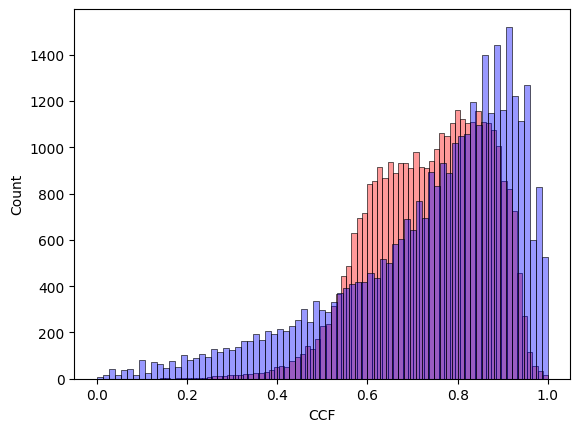

In [ ]:
sns.histplot(y_pred_train, color = 'red', alpha =0.4, bins = 75)
sns.histplot(y_train, color = 'blue', alpha =0.4, bins = 75)

<Axes: xlabel='CCF', ylabel='Count'>

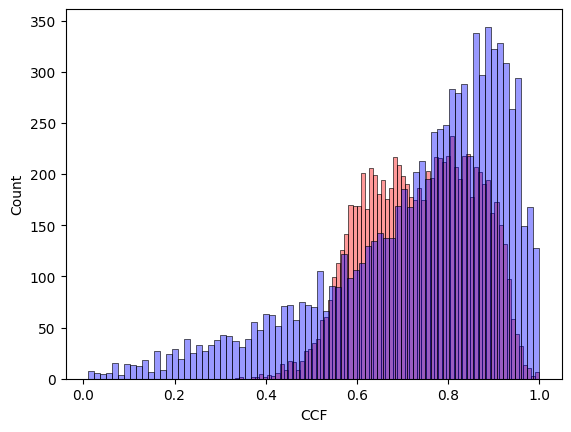

In [ ]:
sns.histplot(y_pred_test, color = 'red', alpha =0.4, bins = 75)
sns.histplot(y_test, color = 'blue', alpha =0.4, bins = 75)

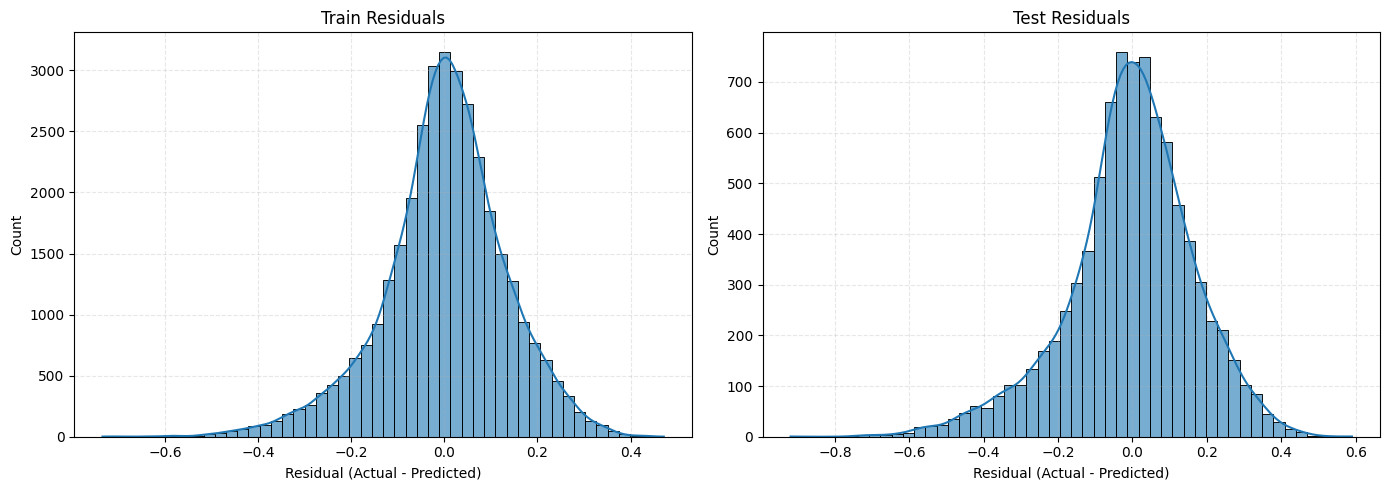

In [ ]:
# Compute residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Plot residual distributions
plt.figure(figsize=(14, 5))

# Train residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals_train, bins=50, kde=True, alpha=0.6)
plt.title('Train Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.grid(alpha=0.3, linestyle='--')

# Test residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals_test, bins=50, kde=True, alpha=0.6)
plt.title('Test Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
